In [1]:
# Fig3 data process
import pandas as pd
from pathlib import Path

# =========================
# 1. File Paths
# =========================
file_path = Path("Your path/Stranded_Occupations_Replication/Data/raw_new/j2jod_22_24/j2jod.csv")

out_excel = Path("Your path/Stranded_Occupations_Replication/Data/temp/j2jod_2023_outflow_results.xlsx")
out_detail_csv = Path("Your path/Stranded_Occupations_Replication/Data/temp/j2jod_2023_outflow_detail.csv")
out_by_origin_csv = Path("Your path/Stranded_Occupations_Replication/Data/temp/j2jod_2023_outflow_by_origin.csv")
out_total_csv = Path("Your path/Stranded_Occupations_Replication/Data/temp/j2jod_2023_outflow_total.csv")

# =========================
# 2. Load Data
# =========================
df = pd.read_csv(file_path, dtype=str)
df.columns = [c.strip() for c in df.columns]

for col in df.columns:
    df[col] = df[col].astype(str).str.strip()

# Numeric variables
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["quarter"] = pd.to_numeric(df["quarter"], errors="coerce")
df["J2J"] = pd.to_numeric(df["J2J"], errors="coerce")

# =========================
# 3. Target Origin Sectors (S level)
# Note: Use real S-level names here
# =========================
target_orig_sectors = {
    "21",
    "22",
    "23",
    "31-33",
    "42",
    "44-45",
    "48-49",
    "51",
    "52",
    "53",
    "54",
    "55",
    "56",
    "61",
    "62",
    "71",
    "72",
    "81",
    "92"
}

# =========================
# 4. Filter for 2023 + S Level
# =========================
sub = df[
    (df["year"] == 2023) &
    (df["ind_level"] == "S") &
    (df["ind_level_orig"] == "S")
].copy()

sub["industry"] = sub["industry"].astype(str).str.strip()
sub["industry_orig"] = sub["industry_orig"].astype(str).str.strip()

# Keep only target origin sectors
sub = sub[sub["industry_orig"].isin(target_orig_sectors)].copy()

# Keep flows to the same sector, so do NOT drop industry == industry_orig
sub = sub.dropna(subset=["J2J"]).copy()

# =========================
# 5. Origin Sector -> Destination Sector Details
# =========================
detail_quarter = (
    sub.groupby(["year", "quarter", "industry_orig", "industry"], as_index=False)["J2J"]
    .sum()
    .sort_values(["industry_orig", "industry", "quarter"])
)

detail_year = (
    sub.groupby(["year", "industry_orig", "industry"], as_index=False)["J2J"]
    .sum()
    .sort_values(["industry_orig", "industry"])
)

# =========================
# 6. Total Outflow from Each Origin Sector to All Sectors
# Including flows to the same sector
# =========================
by_origin = (
    sub.groupby(["year", "industry_orig"], as_index=False)["J2J"]
    .sum()
    .sort_values(["industry_orig"])
    .rename(columns={
        "industry_orig": "origin_sector",
        "J2J": "outflow_total_including_same_sector"
    })
)

# =========================
# 7. Total Aggregate Outflow
# =========================
total_outflow = by_origin["outflow_total_including_same_sector"].sum()

total_df = pd.DataFrame({
    "year": [2023],
    "selected_origin_sectors": ["; ".join(sorted(target_orig_sectors))],
    "total_outflow_including_same_sector": [total_outflow]
})

# =========================
# 8. Optional: Wide Format Matrix (Better for Flow Structure Visualization)
# Rows = Origin Sectors, Columns = Destination Sectors
# =========================
flow_matrix = (
    detail_year.pivot(index="industry_orig", columns="industry", values="J2J")
    .fillna(0)
    .reset_index()
)

# =========================
# 9. Export Results
# =========================
with pd.ExcelWriter(out_excel, engine="openpyxl") as writer:
    detail_quarter.to_excel(writer, sheet_name="detail_quarter", index=False)
    detail_year.to_excel(writer, sheet_name="detail_year", index=False)
    by_origin.to_excel(writer, sheet_name="by_origin", index=False)
    total_df.to_excel(writer, sheet_name="total", index=False)
    flow_matrix.to_excel(writer, sheet_name="flow_matrix", index=False)

detail_year.to_csv(out_detail_csv, index=False, encoding="utf-8-sig")
by_origin.to_csv(out_by_origin_csv, index=False, encoding="utf-8-sig")
total_df.to_csv(out_total_csv, index=False, encoding="utf-8-sig")

print("=== Total Outflow from Each Origin Sector (Including Same Sector) ===")
print(by_origin)

print("\n=== Total Aggregate Outflow ===")
print(total_df)

print("\n=== Origin -> Destination Annual Details (First 20 Rows) ===")
print(detail_year.head(20))

print("\nFiles exported to:")
print(out_excel)
print(out_detail_csv)
print(out_by_origin_csv)
print(out_total_csv)

=== 每个原始部门流向所有部门总人数（包括本部门） ===
    year origin_sector  outflow_total_including_same_sector
0   2023            21                               121959
1   2023            22                                58405
2   2023            23                              1808161
3   2023         31-33                              1855349
4   2023            42                               907691
5   2023         44-45                              3800582
6   2023         48-49                              1584714
7   2023            51                               508029
8   2023            52                               797665
9   2023            53                               443768
10  2023            54                              1790313
11  2023            55                               407314
12  2023            56                              3825027
13  2023            61                              1200184
14  2023            62                              3661187
15  2023 

In [2]:
# Fig3 data process
import pandas as pd
from pathlib import Path

# ─── 1. Load Data ───────────────────────────────────────────────────────────────
file_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/j2jod_2023_outflow_detail.csv")
df = pd.read_csv(file_path)

print("=== Basic Data Information ===")
print(f"Rows: {len(df)}, Columns: {df.shape[1]}")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())

# ─── 2. Define Fossil Fuel Industries (Stranded) ────────────────────────────────
# 2-Digit NAICS: 21, 22, 23, 31-33, 42, 44-45, 48-49
STRAND_INDUSTRIES = {"21", "22", "23", "31-33", "42", "44-45", "48-49"}

# Ensure industry columns are string type (strip extra spaces)
df["industry_orig"] = df["industry_orig"].astype(str).str.strip()
df["industry"]      = df["industry"].astype(str).str.strip()

# ─── 3. Filter: Origin Industries are Fossil Fuel Industries ───────────────────
df_strand = df[df["industry_orig"].isin(STRAND_INDUSTRIES)].copy()
print(f"\nRows after filtering (industry_orig is stranded): {len(df_strand)}")
print("Distribution of industry_orig:")
print(df_strand["industry_orig"].value_counts())

# ─── 4. Validate Flow Variable ─────────────────────────────────────────────────
# Automatically identify numeric columns as flow (exclude industry columns)
non_industry_cols = [c for c in df_strand.columns if c not in ("industry_orig", "industry")]
print(f"\nPotential flow columns: {non_industry_cols}")

# Default to first numeric column as flow; manually specify if multiple columns exist
flow_col = non_industry_cols[0]
print(f"Using flow column: '{flow_col}'")

df_strand[flow_col] = pd.to_numeric(df_strand[flow_col], errors="coerce").fillna(0)

# ─── 5. Aggregate: Total Outflow from Stranded Industries to Each Destination ───
# Keep all destinations regardless of whether they are also fossil fuel industries
result = (
    df_strand
    .groupby("industry", as_index=False)[flow_col]
    .sum()
    .rename(columns={flow_col: "total_outflow"})
)

# ─── 6. Calculate Transition Shares ────────────────────────────────────────────
grand_total = result["total_outflow"].sum()
result["share"] = result["total_outflow"] / grand_total

# Flag if destination industry is also a fossil fuel industry
result["is_strand_dest"] = result["industry"].isin(STRAND_INDUSTRIES)

# Sort by total outflow
result = result.sort_values("total_outflow", ascending=False).reset_index(drop=True)

print(f"\n=== Result Preview (Total Outflow from Fossil Fuel Industries: {grand_total:,.0f}) ===")
print(result.to_string(index=False))

# ─── 7. Save Results ──────────────────────────────────────────────────────────
output_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/fossil_rsupply_j2j.csv")
result.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\nResults saved to: {output_path}")

# ─── 8. Additional: Granular Transition Matrix by Origin Industry ──────────────
detail = df_strand.groupby(["industry_orig", "industry"], as_index=False)[flow_col].sum()
detail = detail.rename(columns={flow_col: "flow"})

# Total outflow for each origin industry
orig_total = detail.groupby("industry_orig")["flow"].sum().rename("orig_total")
detail = detail.join(orig_total, on="industry_orig")
detail["share_by_orig"] = detail["flow"] / detail["orig_total"]
detail["is_strand_dest"] = detail["industry"].isin(STRAND_INDUSTRIES)
detail = detail.sort_values(["industry_orig", "flow"], ascending=[True, False])

detail_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/fossil_rsupply_j2j_detail.csv")
detail.to_csv(detail_path, index=False, encoding="utf-8-sig")
print(f"Granular matrix saved to: {detail_path}")

print("\n=== Granular Matrix Preview (Top 5 per Origin Industry) ===")
print(detail.groupby("industry_orig").head(5).to_string(index=False))

=== 数据基本信息 ===
行数: 380, 列数: 4
year              int64
industry_orig    object
industry         object
J2J               int64
dtype: object

前5行:
   year industry_orig industry    J2J
0  2023            21       11    844
1  2023            21       21  41799
2  2023            21       22   1216
3  2023            21       23  19515
4  2023            21    31-33   9944

筛选后行数（industry_orig 为 strandind）: 140
industry_orig 分布:
industry_orig
21       20
22       20
23       20
31-33    20
42       20
44-45    20
48-49    20
Name: count, dtype: int64

可能的流量列: ['year', 'J2J']
使用流量列: 'year'

=== 结果预览（化石燃料行业总流出人数: 283,220）===
industry  total_outflow  share  is_strand_dest
      11          14161   0.05           False
      21          14161   0.05            True
      81          14161   0.05           False
      72          14161   0.05           False
      71          14161   0.05           False
      62          14161   0.05           False
      61          14161   0.05           F

In [2]:
# Fig3 data process
import pandas as pd
from pathlib import Path

# ─── Load Data ───────────────────────────────────────────────────────────────
file_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/j2jod_2023_outflow_detail.csv")
df = pd.read_csv(file_path)

df["industry_orig"] = df["industry_orig"].astype(str).str.strip()
df["industry"]      = df["industry"].astype(str).str.strip()

# ─── Define Fossil Fuel Industries ────────────────────────────────────────────
STRAND = {"21", "22", "23", "31-33", "42", "44-45", "48-49"}

# ─── Filter records where origin industry is stranded ──────────────────────────
df_strand = df[df["industry_orig"].isin(STRAND)].copy()

# ─── Aggregate: Sum total outflow by destination industry from all stranded origins ─────────────────
result = (
    df_strand
    .groupby("industry", as_index=False)["J2J"]
    .sum()
    .rename(columns={"J2J": "total_outflow"})
)

# ─── Calculate share: denominator = total outflow from stranded industries ─────────────────────────────
grand_total = result["total_outflow"].sum()
result["share"] = result["total_outflow"] / grand_total

# ─── Flag if destination industry is also stranded ──────────────────────────────────────────
result["is_strand_dest"] = result["industry"].isin(STRAND)

result = result.sort_values("total_outflow", ascending=False).reset_index(drop=True)

print(f"Total outflow from stranded industries (denominator): {grand_total:,}")
print()
print(result.to_string(index=False))

# ─── Save Output ────────────────────────────────────────────────────────────────────
output_path = Path("Your path/Stranded_Occupations_Replication/Data/temp/fossil_rsupply_j2j.csv")
result.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\nSaved to: {output_path}")


strandind 总流出人数（分母）: 10,136,861

industry  total_outflow    share  is_strand_dest
   44-45        1754021 0.173034            True
      23        1376374 0.135779            True
      56        1080314 0.106573           False
   31-33        1060045 0.104573            True
   48-49         944920 0.093216            True
      72         860820 0.084920           False
      62         582136 0.057428           False
      42         571110 0.056340            True
      54         408296 0.040278           False
      81         276389 0.027266           False
      61         202727 0.019999           False
      92         156758 0.015464           False
      55         148554 0.014655           False
      71         142745 0.014082           False
      52         137440 0.013558           False
      53         136900 0.013505           False
      21          95812 0.009452            True
      51          94117 0.009285           False
      11          62502 0.006166    

In [5]:
# Fig3 data process
import pandas as pd
from pathlib import Path

# ─── Path Configuration ────────────────────────────────────────────────────────────────
DTA_DIR  = Path("Your path/Stranded_Occupations_Replication/Data/temp/")
CSV_PATH = Path("Your path/Stranded_Occupations_Replication/Data/temp/fossil_rsupply_j2j.csv")
OUT_PATH = Path("Your path/Stranded_Occupations_Replication/Data/temp/merged_j2j_skill.csv")

# ─── 1. Load job-to-job transition shares ─────────────────────────────────────────────────────
j2j = pd.read_csv(CSV_PATH)
j2j["industry"] = j2j["industry"].astype(str).str.strip()

# ─── 2. Read dta files one by one, label skill_type, and append vertically (generated by Stata first) ─────────────────────────
TAGS = ["rm", "nrc", "nrm", "rc"]
frames = []

for tag in TAGS:
    df = pd.read_stata(DTA_DIR / f"sum_8k1{tag}.dta")
    df["skill_type"] = tag
    frames.append(df)
    print(f"[{tag}] shape={df.shape}  columns: {df.columns.tolist()}")

# ─── 3. Vertically concatenate into sum_8k1 ────────────────────────────────────────────────────
combined = pd.concat(frames, ignore_index=True)
print(f"\nShape after concatenation: {combined.shape}")
print("Columns:", combined.columns.tolist())
print("\nRow count by skill_type:")
print(combined["skill_type"].value_counts())

# ─── 4. Combine four columns into one sum_8k1 (four columns are complementary, take non-NaN value per row) ────────────
skill_cols    = ["sum_8k1rm", "sum_8k1nrc", "sum_8k1nrm", "sum_8k1rc"]
existing_cols = [c for c in skill_cols if c in combined.columns]
print(f"\nFound skill columns: {existing_cols}")

combined["sum_8k1"] = combined[existing_cols].bfill(axis=1).iloc[:, 0]
print("Non-missing count for sum_8k1:", combined["sum_8k1"].notna().sum())

# ─── 5. Check sample values for each column (confirm merge key) ────────────────────────────────────────
for col in combined.columns:
    sample = combined[col].dropna().unique()[:5]
    print(f"  {col}: {sample}")

# ─── 6. Set merge key column (adjust based on step 5 output) ──────────────────────────────────────
NAICS_COL = "naics_group"

combined[NAICS_COL] = combined[NAICS_COL].astype(str).str.strip()

# ─── 7. Merge: naics_name from dta ↔ industry from j2j ──────────────────────────
merged = combined.merge(
    j2j[["industry", "total_outflow", "share", "is_strand_dest"]],
    left_on=NAICS_COL,
    right_on="industry",
    how="left"
)

# Check merge matching status
n_matched   = merged["share"].notna().sum()
n_unmatched = merged["share"].isna().sum()
print(f"\nMatched rows: {n_matched}, Unmatched rows: {n_unmatched}")
if n_unmatched > 0:
    print("Unmatched values:")
    print(merged.loc[merged["share"].isna(), NAICS_COL].dropna().unique()[:20])

# ─── 8. Save output ─────────────────────────────────────────────────────────────────
merged.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print(f"\nSaved to: {OUT_PATH}  shape={merged.shape}")

[rm] shape=(20, 33)  列: ['NAICS2022', 'NAICS2022title', 'nem_indcode', 'Occupationtype', 'Industrytype', 'Occupationcode', 'Occupationtitle', 'Industrytitle', 'Employment', 'PercentofIndustry', 'PercentofOccupation', 'L', 'M', 'N', 'Numericchange202333', 'Percentchange202333', 'occupation_code', 'occupation_code_match', 'strand_ind', 'type_skill_all', 'nrm', 'rm', 'nrc', 'rc', 'simocconly_8k1nrm', 'simocconly_8k1rm', 'simocconly_8k1nrc', 'simocconly_8k1rc', 'naics2', 'naics_group', 'naics_name', 'sum_8k1rm', 'skill_type']
[nrc] shape=(20, 33)  列: ['NAICS2022', 'NAICS2022title', 'nem_indcode', 'Occupationtype', 'Industrytype', 'Occupationcode', 'Occupationtitle', 'Industrytitle', 'Employment', 'PercentofIndustry', 'PercentofOccupation', 'L', 'M', 'N', 'Numericchange202333', 'Percentchange202333', 'occupation_code', 'occupation_code_match', 'strand_ind', 'type_skill_all', 'nrm', 'rm', 'nrc', 'rc', 'simocconly_8k1nrm', 'simocconly_8k1rm', 'simocconly_8k1nrc', 'simocconly_8k1rc', 'naics2',

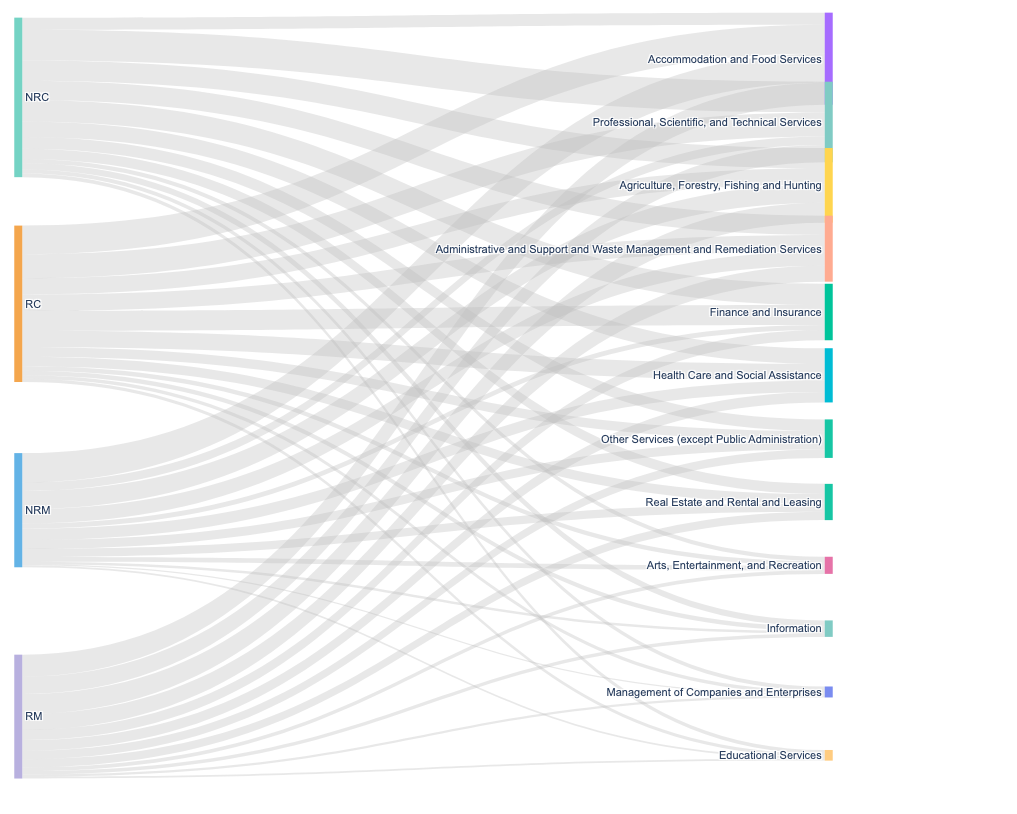

SVG 已保存：/Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/Fig3A.svg
筛选后保留 52 行，右侧 12 个行业节点。


In [10]:
# Fig3A picture drawing
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path

# ========================= File Paths =========================
input_csv = Path("Your path/Stranded_Occupations_Replication/Data/temp/merged_j2j_skill.csv")
output_svg = Path("Your path/Stranded_Occupations_Replication/Data/temp/Fig3A.svg")

# ========================= Read & Filter =========================
df = pd.read_csv(input_csv)
if "is_strand_dest" not in df.columns:
    raise ValueError("Column not found in data: is_strand_dest")
df["is_strand_dest"] = df["is_strand_dest"].astype(str).str.strip().str.lower()
df = df[~df["is_strand_dest"].isin(["true", "1", "yes"])].copy()

# ========================= Left Nodes =========================
left_order = ["NRC", "RC", "NRM", "RM"]
col_map = {
    "NRC": "sum_8k1nrc",
    "RC": "sum_8k1rc",
    "NRM": "sum_8k1nrm",
    "RM": "sum_8k1rm",
}

# ========================= Wide to Long Format =========================
parts = []
for left_name in left_order:
    value_col = col_map[left_name]
    tmp = df[["naics_name", value_col]].copy()
    tmp = tmp.rename(columns={value_col: "value"})
    tmp["left_type"] = left_name
    parts.append(tmp)
flow_df = pd.concat(parts, ignore_index=True)

# ========================= Clean Numeric Values =========================
flow_df["value"] = pd.to_numeric(flow_df["value"], errors="coerce")
flow_df = flow_df.dropna(subset=["value"])
flow_df = flow_df[flow_df["value"] > 0].copy()
flow_df["naics_name"] = flow_df["naics_name"].astype(str).str.strip()
flow_df = flow_df[flow_df["naics_name"] != ""]
flow_df = flow_df[flow_df["naics_name"].str.lower() != "nan"]

# ========================= Aggregation =========================
flow_df = flow_df.groupby(["left_type", "naics_name"], as_index=False)["value"].sum()

# ========================= Right Node Sorting =========================
right_totals = (
    flow_df.groupby("naics_name", as_index=False)["value"]
    .sum()
    .sort_values("value", ascending=False)
    .reset_index(drop=True)
)
right_order = right_totals["naics_name"].tolist()

# ========================= Node Labels =========================
labels = left_order + right_order
label_to_idx = {label: i for i, label in enumerate(labels)}

# ========================= Flow Data =========================
sources = [label_to_idx[x] for x in flow_df["left_type"]]
targets = [label_to_idx[x] for x in flow_df["naics_name"]]
values = flow_df["value"].tolist()

# ========================= Node Colors =========================
import hashlib

def stable_color(name, palette):
    """
    Generate stable color for node names:
    Same name always gets same color across scripts and orders
    """
    key = str(name).strip().lower()
    h = hashlib.md5(key.encode("utf-8")).hexdigest()
    idx = int(h, 16) % len(palette)
    return palette[idx]

left_colors = {
    "NRC": "#74d3c4",
    "RC": "#f4a64d",
    "NRM": "#63b3e6",
    "RM": "#b8b0df",
}

palette = [
    "#ef6f6c", "#16c6a4", "#b56ce8", "#f3a35c", "#18c7de", "#e673a8",
    "#b9df74", "#f3ca52", "#7a8cf0", "#ff7f50", "#00c49a", "#a66cff",
    "#ffb347", "#00bcd4", "#ff6fae", "#9ccc65", "#e1bee7", "#ffd54f",
    "#90caf9", "#ffab91", "#80cbc4", "#c5e1a5", "#ce93d8", "#ffcc80"
]

naics_color_map = {
    n: stable_color(n, palette)
    for n in right_order
}

node_colors = [left_colors[x] for x in left_order]
node_colors += [naics_color_map[x] for x in right_order]

# ========================= Node Positions =========================
n_left = len(left_order)
n_right = len(right_order)

# Left: 4 nodes, vertically centered with margins
left_x = [0.01] * n_left
left_y = np.linspace(0.10, 0.90, n_left).tolist()

# Right: Compact arrangement, not full height
# Right style: Nodes start from top with even spacing but overall top-aligned
# ========================= Node Positions =========================
right_x = [0.99] * n_right
if n_right == 1:
    right_y = [0.5]
else:
    # Reduced range → larger physical spacing between nodes
    y_span_top = 0.05
    y_span_bottom = 0.95
    right_y = np.linspace(y_span_top, y_span_bottom, n_right).tolist()

x = left_x + right_x
y = left_y + right_y

# ========================= Create Sankey Diagram =========================
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="fixed",
            node=dict(
                pad=20,             # Modified: Node spacing, original 15, reduced for tighter right side
                thickness=8,        # Key modification: Node thickness, original default 20, changed to 8 for slimmer look
                line=dict(color="rgba(0,0,0,0)", width=0),
                label=labels,
                color=node_colors,
                x=x,
                y=y,
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color="rgba(190,190,190,0.35)",  # Modified: More transparent links for cleaner visual
            ),
        )
    ]
)

# ========================= Canvas Dimensions =========================
# Modified: Height no longer grows linearly with node count, fixed appropriate height
height = max(800, 40 * n_right + 200)   # Original 30 → 40

fig.update_layout(
    title="",
    font=dict(size=11, family="Arial"),
    width=1200,
    height=height,
    margin=dict(l=10, r=180, t=20, b=20),  # Modified: More right margin for labels
    paper_bgcolor="white",
    plot_bgcolor="white",
)
fig.show()
# ========================= Export SVG =========================
fig.write_image(output_svg, format="svg")
print(f"SVG saved to: {output_svg}")
print(f"Retained {len(df):,} rows after filtering, {n_right} industry nodes on the right.")

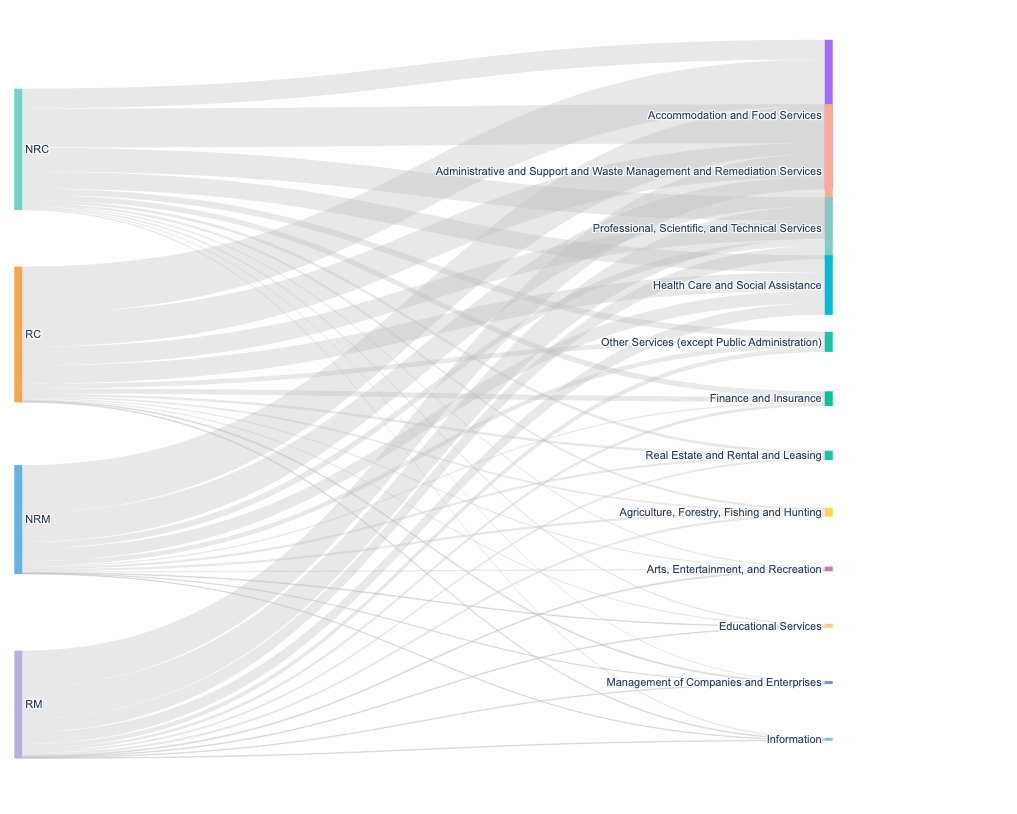

SVG 已保存：/Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/Fig3B.svg
筛选后保留 52 行，右侧 12 个行业节点。
长表已保存：/Users/huangqing/Documents/paper/strand_labor/Stranded_Occupations_Replication/Data/temp/Fig3B.csv


In [8]:
# Fig3B picture drawing 
"""
Functions:
1. Read CSV data
2. Multiply 'share' by non-null values of sum_8k1nrc, sum_8k1rc, sum_8k1nrm, sum_8k1rm respectively
3. Organize the multiplied new values into Sankey diagram long-format data
4. Fixed left nodes: NRC, RC, NRM, RM
5. Right nodes: naics_name, sorted by total inflow from largest to smallest
6. Export Sankey diagram in SVG format
"""

# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path

# File paths
input_csv = Path("Your path/Stranded_Occupations_Replication/Data/temp/merged_j2j_skill.csv")
output_svg = Path("Your path/Stranded_Occupations_Replication/Data/temp/Fig3B.svg")
output_flow_csv = Path("Your path/Stranded_Occupations_Replication/Data/temp/Fig3B.csv")

# ========================= Read & Filter =========================
df = pd.read_csv(input_csv)
if "is_strand_dest" not in df.columns:
    raise ValueError("Column not found in data: is_strand_dest")
df["is_strand_dest"] = df["is_strand_dest"].astype(str).str.strip().str.lower()
df = df[~df["is_strand_dest"].isin(["true", "1", "yes"])].copy()

# ========================= Left Nodes =========================
left_order = ["NRC", "RC", "NRM", "RM"]
col_map = {
    "NRC": "sum_8k1nrc",
    "RC":  "sum_8k1rc",
    "NRM": "sum_8k1nrm",
    "RM":  "sum_8k1rm",
}

# ========================= Data Cleaning =========================
df["share"] = pd.to_numeric(df["share"], errors="coerce")
for col in col_map.values():
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ========================= Generate share × sum Columns =========================
for left_name, raw_col in col_map.items():
    new_col = raw_col + "_share"
    df[new_col] = np.where(df[raw_col].notna(), df["share"] * df[raw_col], np.nan)

# ========================= Convert Wide to Long Format =========================
parts = []
for left_name in left_order:
    raw_col   = col_map[left_name]
    value_col = raw_col + "_share"
    tmp = df[["naics_name", value_col]].copy()
    tmp = tmp.rename(columns={value_col: "value"})
    tmp["left_type"] = left_name
    parts.append(tmp)
flow_df = pd.concat(parts, ignore_index=True)

# ========================= Clean Numeric Values =========================
flow_df["value"] = pd.to_numeric(flow_df["value"], errors="coerce")
flow_df = flow_df.dropna(subset=["value"])
flow_df = flow_df[flow_df["value"] > 0].copy()
flow_df["naics_name"] = flow_df["naics_name"].astype(str).str.strip()
flow_df = flow_df[flow_df["naics_name"] != ""]
flow_df = flow_df[flow_df["naics_name"].str.lower() != "nan"]

# ========================= Aggregation =========================
flow_df = flow_df.groupby(["left_type", "naics_name"], as_index=False)["value"].sum()
flow_df.to_csv(output_flow_csv, index=False, encoding="utf-8-sig")

# ========================= Right Node Sorting =========================
right_totals = (
    flow_df.groupby("naics_name", as_index=False)["value"]
    .sum()
    .sort_values("value", ascending=False)
    .reset_index(drop=True)
)
right_order = right_totals["naics_name"].tolist()

# ========================= Node Labels =========================
labels = left_order + right_order
label_to_idx = {label: i for i, label in enumerate(labels)}

# ========================= Link Data =========================
sources = [label_to_idx[x] for x in flow_df["left_type"]]
targets = [label_to_idx[x] for x in flow_df["naics_name"]]
values  = flow_df["value"].tolist()

# ========================= Node Colors =========================
import hashlib

def stable_color(name, palette):
    """
    Generate stable color for node names:
    Same name always gets same color across scripts and orders
    """
    key = str(name).strip().lower()
    h = hashlib.md5(key.encode("utf-8")).hexdigest()
    idx = int(h, 16) % len(palette)
    return palette[idx]

left_colors = {
    "NRC": "#74d3c4",
    "RC":  "#f4a64d",
    "NRM": "#63b3e6",
    "RM":  "#b8b0df",
}

palette = [
    "#ef6f6c", "#16c6a4", "#b56ce8", "#f3a35c", "#18c7de", "#e673a8",
    "#b9df74", "#f3ca52", "#7a8cf0", "#ff7f50", "#00c49a", "#a66cff",
    "#ffb347", "#00bcd4", "#ff6fae", "#9ccc65", "#e1bee7", "#ffd54f",
    "#90caf9", "#ffab91", "#80cbc4", "#c5e1a5", "#ce93d8", "#ffcc80"
]

naics_color_map = {
    n: stable_color(n, palette)
    for n in right_order
}

node_colors = [left_colors[x] for x in left_order]
node_colors += [naics_color_map[x] for x in right_order]

# ========================= Node Positions (Sync with no-linkage version) =========================
n_left  = len(left_order)
n_right = len(right_order)

# Sync: Left x changed from 0.11 → 0.01
left_x = [0.01] * n_left
left_y = np.linspace(0.12, 0.90, n_left).tolist()

# Sync: Right x changed from 0.9 → 0.99, y range from 0.01~0.99 → 0.05~0.95
right_x = [0.99] * n_right

if n_right == 1:
    right_y = [0.50]
elif n_right == 2:
    right_y = [0.35, 0.65]
elif n_right == 3:
    right_y = [0.22, 0.50, 0.78]
else:
    # Add extra spacing for the first two nodes
    base_y = np.linspace(0.08, 0.92, n_right).tolist()
    base_y[1] = base_y[1] + 0.035   # Move the second node down slightly
    right_y = base_y

x = left_x + right_x
y = left_y + right_y

# ========================= Create Sankey Diagram =========================
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="fixed",
            node=dict(
                pad=20,         # Sync: Original 30 → 20
                thickness=8,    # Sync: Original 10 → 8
                line=dict(color="rgba(0,0,0,0)", width=0),
                label=labels,
                color=node_colors,
                x=x,
                y=y,
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color="rgba(190,190,190,0.35)",
            ),
        )
    ]
)

# ========================= Canvas Dimensions (Sync with no-linkage version) =========================
# Sync: Original fixed 1800 → Dynamic calculation based on node count
height = max(800, 50 * n_right + 200)

fig.update_layout(
    title="",
    font=dict(size=11, family="Arial"),
    width=1200,                             # Sync: Original 1500 → 1200
    height=height,
    margin=dict(l=10, r=180, t=80, b=40),  # Sync: Original l=0,r=0 → l=10,r=180
    paper_bgcolor="white",
    plot_bgcolor="white",
)

fig.show()

# ========================= Export SVG =========================
fig.write_image(output_svg, format="svg")
print(f"SVG saved to: {output_svg}")
print(f"Retained {len(df):,} rows after filtering, {n_right} industry nodes on the right.")
print(f"Long-format data saved to: {output_flow_csv}")